## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy.spatial.distance import pdist, squareform

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
figures_path = find_figures_path()

In [4]:
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [5]:
metadata = pd.read_csv(f"{data_path}/metadata_sample.csv", index_col=[0], low_memory=False).sort_index()
taxonomy = pd.read_csv(f"{data_path}/taxonomy_sample.csv", index_col=[0]).sort_index() * 100
pathways = pd.read_csv(f"{data_path}/pathways_sample.csv", index_col=[0]).sort_index() * 100

metadata = metadata.query("sample_id in @taxonomy.index")

In [6]:
print(f"metadata: {metadata.shape} | taxonomy: {taxonomy.shape} | pathways: {pathways.shape}")

metadata: (128, 141) | taxonomy: (128, 202) | pathways: (128, 398)


# Figure 1A - Disease Overview

In [ ]:
diseases_df = (metadata['study_condition']
    .value_counts()
    .reset_index()
    .rename(columns={'study_condition': 'disease', 'count': 'count'})
    .query("disease != 'control'"))

In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))

sns.barplot(
    data=diseases_df,
    x="count", y="disease",
    color="#969696",
    edgecolor="none",
    ax=ax
)
ax.set(xlabel="N samples", ylabel="")
sns.despine(left=False, right=True, top=True, bottom=False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1A.png", dpi=300)

# Figure 1B - Count by Countries

In [ ]:
count_by_country_df = metadata['country'].value_counts().reset_index()

In [ ]:
fig, ax = plt.subplots(figsize=(7, 9))

sns.barplot(
    data=count_by_country_df,
    x='count', y='country',
    color='#969696',
    ax=ax,
    edgecolor='none'
)
ax.set(xlabel="N samples", ylabel="")
sns.despine(left=False, right=True, top=True, bottom=False)

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1B.png", dpi=300)

# Figure 1C - Age Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    metadata.age,
    color='#969696',
    edgecolor='none'
)
sns.despine(left=False, right=True, top=True, bottom=False)
ax.set(xlabel="age")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1C.png", dpi=300)

# Figure 1D - Gender Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    metadata.gender,
    color='#969696',
    edgecolor='none'
)
sns.despine(left=False, right=True, top=True, bottom=False)
ax.set_xlabel('gender')

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1D.png", dpi=300)

# Figure 1E - Taxonomy Distribution

In [ ]:
samples_per_species = (taxonomy > 0).sum(axis=0).values
species_per_sample = (taxonomy > 0).sum(axis=1).values

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(samples_per_species, bins=10, color='#e89e53ff', edgecolor='none', ax=axes[0])
sns.histplot(species_per_sample, bins=10, color='#e89e53ff', edgecolor='none', ax=axes[1])

sns.despine(left=False, right=True, top=True, bottom=False)
axes[0].set_ylabel("Number of species")
axes[1].set_ylabel("Number of samples")
axes[0].set_xlabel("Number of samples")
axes[1].set_xlabel("Number of species")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1E.png", dpi=300)

# Figure 1F - Pathways Distribution

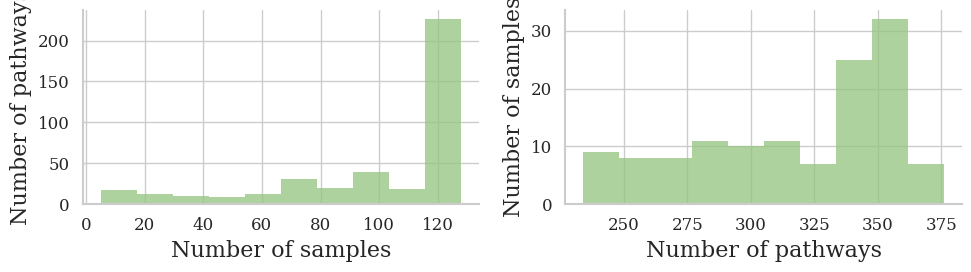

In [24]:
samples_per_pathway = (pathways > 0).sum(axis=0).values
pathways_per_sample = (pathways > 0).sum(axis=1).values

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(samples_per_pathway, bins=10, color='#93c47dff', edgecolor='none', ax=axes[0])
sns.histplot(pathways_per_sample, bins=10, color='#93c47dff', edgecolor='none', ax=axes[1])

sns.despine(left=False, right=True, top=True, bottom=False)
axes[0].set_ylabel("Number of pathways")
axes[1].set_ylabel("Number of samples")
axes[0].set_xlabel("Number of samples")
axes[1].set_xlabel("Number of pathways")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1F.png", dpi=300)

# Zuza approach - Figure 1G - Taxonomy vs Pathways Bray-Curtis Distance

In [10]:
pathways_scaled = pathways / 10

dmT = squareform(pdist(taxonomy, 'braycurtis'))
dmP = squareform(pdist(pathways_scaled, 'braycurtis'))

# Get indices of upper triangle only
# e.g. for A,B,C,D: (A,B), (A,C), (A,D), (B,C), (B,D), (C,D)
upper_tri_idx = np.triu_indices(dmT.shape[0], k=1)

# Build a DataFrame of all unique pairs with their distances
# e.g.:  sample1  sample2  dist
#           A        B     0.2
#           A        C     0.4
#           A        D     0.6
#           B        C     0.8
#           B        D     0.3
#           C        D     0.5
pairs_df = pd.DataFrame({
    'sample1': taxonomy.index[upper_tri_idx[0]],
    'sample2': taxonomy.index[upper_tri_idx[1]],
    'taxonomy_dist': dmT[upper_tri_idx],
    'pathways_dist': dmP[upper_tri_idx],
})

# For each sample, compute mean distance from its sample1 perspective
# e.g.:  A → mean(AB, AC, AD) = mean(0.2, 0.4, 0.6)  → 3 values
#         B → mean(BC, BD)     = mean(0.8, 0.3)        → 2 values
#         C → mean(CD)         = mean(0.5)              → 1 value
#         D → doesn't appear as sample1 at all!
# ISSUE: unequal number of values per sample
mean_as_sample1 = pairs_df.groupby('sample1')[['taxonomy_dist', 'pathways_dist']].mean()

# For each sample, compute mean distance from its sample2 perspective
# e.g.:  A → doesn't appear as sample2 at all!
#         B → mean(AB)         = mean(0.2)              → 1 value
#         C → mean(AC, BC)     = mean(0.4, 0.8)         → 2 values
#         D → mean(AD, BD, CD) = mean(0.6, 0.3, 0.5)   → 3 values
# ISSUE: unequal number of values per sample, A missing entirely
mean_as_sample2 = pairs_df.groupby('sample2')[['taxonomy_dist', 'pathways_dist']].mean()

# Concatenate both perspectives — most samples appear twice, but:
# - A (first): appears only once (only in mean_as_sample1)
# - D (last):  appears only once (only in mean_as_sample2)
# e.g.:  A → 0.400  (once)
#         B → 0.550, 0.200  (twice)
#         C → 0.500, 0.600  (twice)
#         D → 0.467  (once)
temp_res = pd.concat([mean_as_sample1, mean_as_sample2])

# Average the two perspectives per sample
# ISSUE: averages two group means of UNEQUAL sizes → not the same as overall mean
# e.g.:  A → 0.400                         (correct, only one value)
#         B → (0.550 + 0.200) / 2 = 0.375  ≠  mean(0.2, 0.8, 0.3) = 0.433
#         C → (0.500 + 0.600) / 2 = 0.550  ≠  mean(0.4, 0.8, 0.5) = 0.567
#         D → 0.467                         (correct, only one value)
result = temp_res.groupby(level=0).mean()

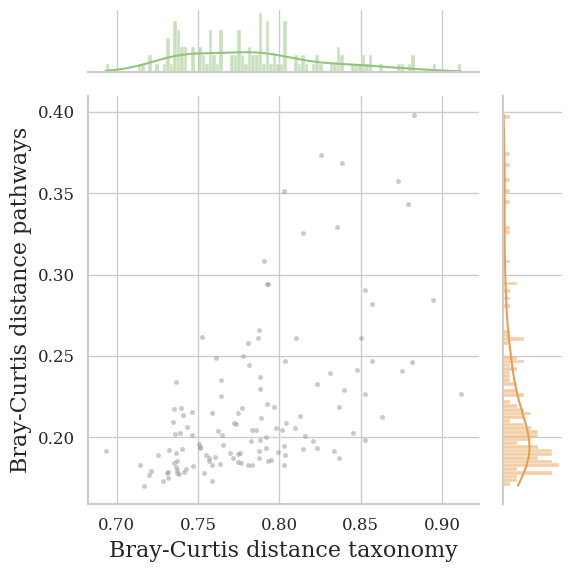

In [27]:
g = sns.JointGrid(data=result, x="taxonomy_dist", y="pathways_dist")

sns.scatterplot(data=result, x="taxonomy_dist", y="pathways_dist",
                s=10, alpha=0.5, edgecolor=None, color="#969696", ax=g.ax_joint)
sns.histplot(data=result, x="taxonomy_dist", kde=True, bins=100,
             edgecolor=None, color="#93c47dff", ax=g.ax_marg_x)
sns.histplot(data=result, y="pathways_dist", kde=True, bins=100,
             edgecolor=None, color="#e89e53ff", ax=g.ax_marg_y)

g.ax_joint.set_xlabel("Bray-Curtis distance taxonomy")
g.ax_joint.set_ylabel("Bray-Curtis distance pathways")

plt.tight_layout()
plt.show()

# Compare: with pathways scaling (/ 10) vs without
####  Same Zuza approach for both — only difference is pathways_scaled vs pathways

In [18]:
def zuza_result(taxonomy, pathways):
    """Compute per-sample average Bray-Curtis distances using Zuza approach."""
    dmT = squareform(pdist(taxonomy, 'braycurtis'))
    dmP = squareform(pdist(pathways, 'braycurtis'))

    upper_tri_idx = np.triu_indices(dmT.shape[0], k=1)

    pairs_df = pd.DataFrame({
        'sample1': taxonomy.index[upper_tri_idx[0]],
        'sample2': taxonomy.index[upper_tri_idx[1]],
        'taxonomy_dist': dmT[upper_tri_idx],
        'pathways_dist': dmP[upper_tri_idx],
    })

    mean_as_sample1 = pairs_df.groupby('sample1')[['taxonomy_dist', 'pathways_dist']].mean()
    mean_as_sample2 = pairs_df.groupby('sample2')[['taxonomy_dist', 'pathways_dist']].mean()

    return pd.concat([mean_as_sample1, mean_as_sample2]).groupby(level=0).mean()

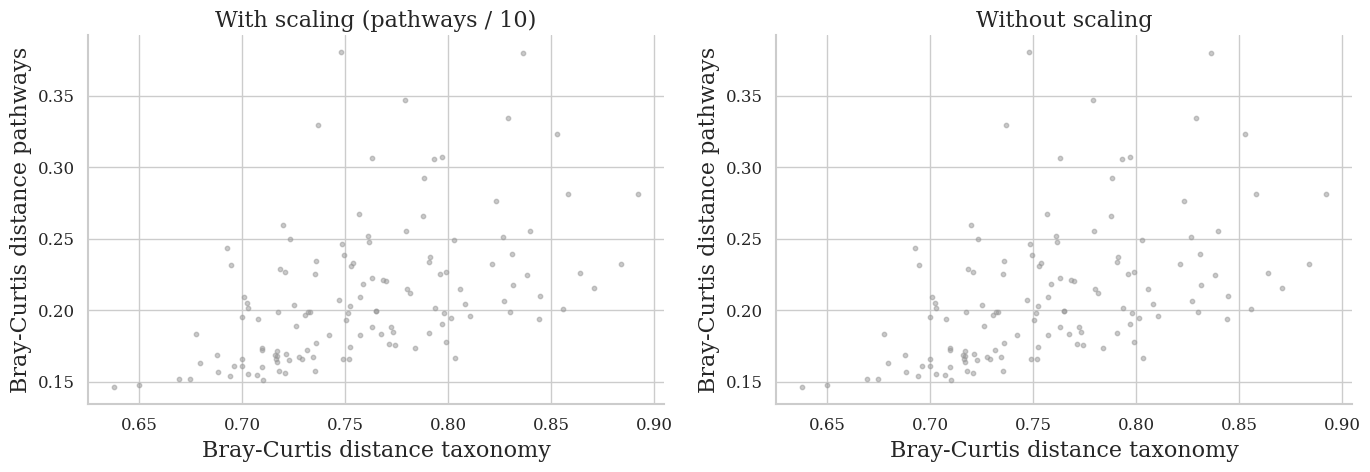

In [19]:
result_scaled    = zuza_result(taxonomy, pathways / 10)
result_no_scale  = zuza_result(taxonomy, pathways)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, res, title in zip(axes,
                          [result_scaled, result_no_scale],
                          ["With scaling (pathways / 10)", "Without scaling"],
                          strict=True):
    ax.scatter(res['taxonomy_dist'], res['pathways_dist'],
               s=10, alpha=0.5, color="#969696")
    ax.set_xlabel("Bray-Curtis distance taxonomy")
    ax.set_ylabel("Bray-Curtis distance pathways")
    ax.set_title(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# WN approach - Figure 1G - Taxonomy vs Pathways Bray-Curtis Distance

In [30]:
dmT = squareform(pdist(taxonomy, 'braycurtis'))
dmP = squareform(pdist(pathways_scaled, 'braycurtis'))

# Set diagonal to nan to exclude self-distance (always 0) from mean
np.fill_diagonal(dmT, np.nan)
np.fill_diagonal(dmP, np.nan)

# Per-sample average distance — row mean, equal weight to all 127 distances
# e.g. for sample A: mean(dist(A,B), dist(A,C), ...) over all other samples
result = pd.DataFrame({
    'taxonomy_dist': np.nanmean(dmT, axis=1),
    'pathways_dist': np.nanmean(dmP, axis=1),
}, index=taxonomy.index)

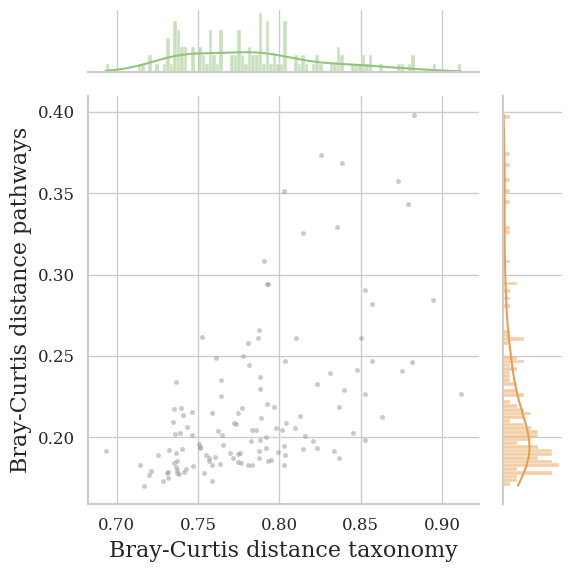

In [31]:
g = sns.JointGrid(data=result, x="taxonomy_dist", y="pathways_dist")

sns.scatterplot(data=result, x="taxonomy_dist", y="pathways_dist",
                s=10, alpha=0.5, edgecolor=None, color="#969696", ax=g.ax_joint)
sns.histplot(data=result, x="taxonomy_dist", kde=True, bins=100,
             edgecolor=None, color="#93c47dff", ax=g.ax_marg_x)
sns.histplot(data=result, y="pathways_dist", kde=True, bins=100,
             edgecolor=None, color="#e89e53ff", ax=g.ax_marg_y)

g.ax_marg_x.yaxis.set_major_locator(MaxNLocator(integer=True))
g.ax_marg_y.xaxis.set_major_locator(MaxNLocator(integer=True))
g.ax_joint.set_xlabel("Bray-Curtis distance taxonomy")
g.ax_joint.set_ylabel("Bray-Curtis distance pathways")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1G.png", dpi=300)
plt.show()

# WN approach - Figure 1G B - Std of Bray-Curtis Distance

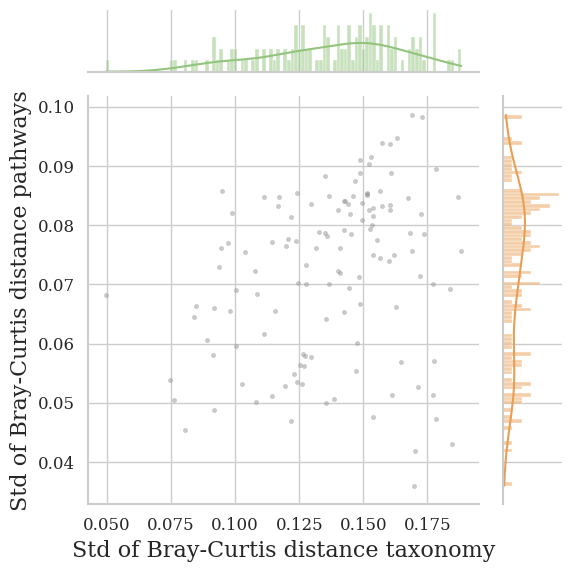

In [32]:
# Per-sample std of distances — how consistently unusual is each sample?
# High std → close to some samples, far from others (belongs to a subgroup)
# Low std  → uniformly distant from everyone (true global outlier)
result_std = pd.DataFrame({
    'taxonomy_std': np.nanstd(dmT, axis=1),
    'pathways_std': np.nanstd(dmP, axis=1),
}, index=taxonomy.index)

g = sns.JointGrid(data=result_std, x="taxonomy_std", y="pathways_std")

sns.scatterplot(data=result_std, x="taxonomy_std", y="pathways_std",
                s=10, alpha=0.5, edgecolor=None, color="#969696", ax=g.ax_joint)
sns.histplot(data=result_std, x="taxonomy_std", kde=True, bins=100,
             edgecolor=None, color="#93c47dff", ax=g.ax_marg_x)
sns.histplot(data=result_std, y="pathways_std", kde=True, bins=100,
             edgecolor=None, color="#e89e53ff", ax=g.ax_marg_y)

g.ax_marg_x.yaxis.set_major_locator(MaxNLocator(integer=True))
g.ax_marg_y.xaxis.set_major_locator(MaxNLocator(integer=True))
g.ax_joint.set_xlabel("Std of Bray-Curtis distance taxonomy")
g.ax_joint.set_ylabel("Std of Bray-Curtis distance pathways")

plt.tight_layout()
plt.savefig(f"{figures_path}/Fig1G_B.png", dpi=300)
plt.show()